In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
#3.1.1.1.2. Load the dataset into a pandas DataFrame
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Concept and technology of AI/online_shoppers_intention.csv")

# Display basic information
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


#3.1.1.1.3 Dataset Creation and Access
#A
Creation: The Online Shoppers Purchasing Intention dataset was created by Sakaray, Polat, Katircioglu, and Kastro and published in 2018.
#B
Source & Access: The dataset was obtained from the UCI Machine Learning Repository and accessed in CSV format for analysis.

Purpose of Creation: It was designed to analyze and predict whether an online shopping session results in a purchase based on user behavior and session attributes.

#3.1.1.1.3 Alignment with United Nations Sustainable Development Goals (UNSDG)
#C
This dataset aligns with UNSDG 8 – Decent Work and Economic Growth.
By analyzing online consumer behavior and predicting purchasing intention, the dataset supports improving e-commerce efficiency, optimizing digital business strategies, and enhancing economic productivity. Insights derived from this data can help businesses increase revenue, reduce inefficiencies in online platforms, and contribute to sustainable economic growth through improved digital commerce systems.

In [36]:
#3.1.1.1.4. Selecting Features and Target Variable

# Target variable
target = "Revenue"

# Feature variables
features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

# Keep only required columns
df = df[features + [target]]

# Preview dataset
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [37]:
#3.1.1.1.5 Display Attribute Descriptions

attribute_description = pd.DataFrame({
    "Attribute": df.columns,
    "Description": [
        "Number of administrative pages visited",
        "Time spent on administrative pages",
        "Number of informational pages visited",
        "Time spent on informational pages",
        "Number of product-related pages visited",
        "Time spent on product-related pages",
        "Bounce rate of the visitor",
        "Exit rate of the visitor",
        "Page value before purchase",
        "Closeness to a special day",
        "Month of the visit",
        "Operating system used",
        "Browser used",
        "Geographical region",
        "Traffic source type",
        "Type of visitor",
        "Whether the visit was on a weekend",
        "Whether a purchase was made (Target variable)"
    ]
})

attribute_description

,Attribute,Description
0,Administrative,Number of administrative pages visited
1,Administrative_Duration,Time spent on administrative pages
2,Informational,Number of informational pages visited
3,Informational_Duration,Time spent on informational pages
4,ProductRelated,Number of product-related pages visited
5,ProductRelated_Duration,Time spent on product-related pages
6,BounceRates,Bounce rate of the visitor
7,ExitRates,Exit rate of the visitor
8,PageValues,Page value before purchase
9,SpecialDay,Closeness to a special day


In [38]:
#3.1.1.1.6. Dataset Suitability and Class Distribution

# Check class imbalance of target variable
df[target].value_counts()
# Summary statistics for numerical features
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


#2. Exploratory Data Analysis (EDA):

In [39]:
#3.1.1.2(a) Perform data cleaning and compute summary statistics for the dataset
# Check the number of rows and columns in the dataset
df.shape

(12330, 18)

In [40]:
# Display the first five rows of the dataset
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [41]:
# Get information about data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [42]:
# Generate summary statistics for numerical features
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [43]:
# Check for missing values across all columns
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [44]:
# Count the occurrences of each class in the target variable
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


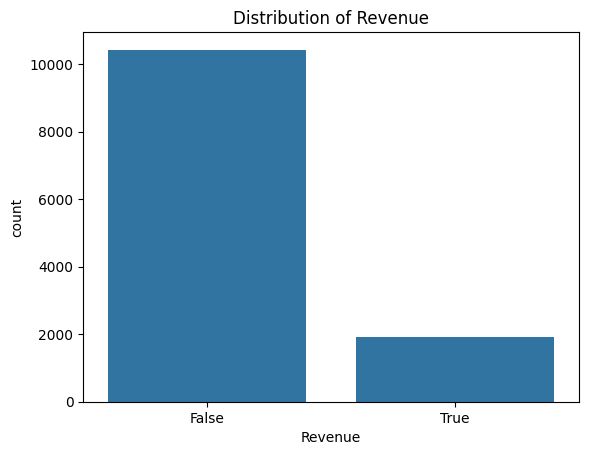

In [45]:
# Visualize the class distribution of the target variable
sns.countplot(x='Revenue', data=df)
plt.title("Distribution of Revenue")
plt.show()

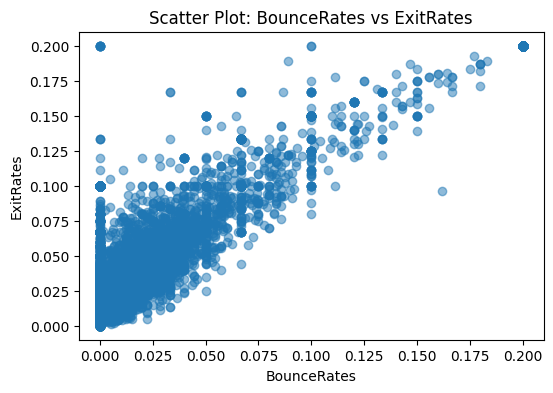

In [46]:
# Scatter plot between BounceRates and ExitRates
plt.figure(figsize=(6, 4))
plt.scatter(df['BounceRates'], df['ExitRates'], alpha=0.5)
plt.title("Scatter Plot: BounceRates vs ExitRates")
plt.xlabel("BounceRates")
plt.ylabel("ExitRates")
plt.show()


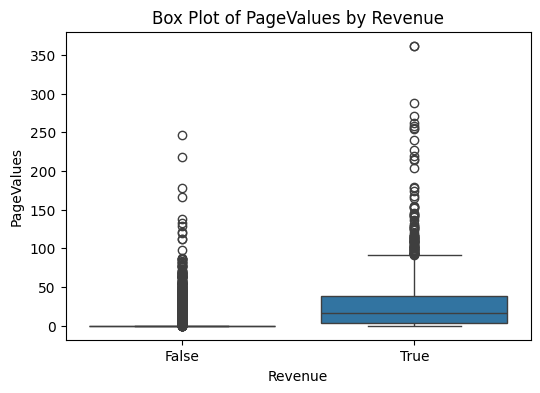

In [47]:
# Box plot for PageValues grouped by Revenue
plt.figure(figsize=(6, 4))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("Box Plot of PageValues by Revenue")
plt.show()

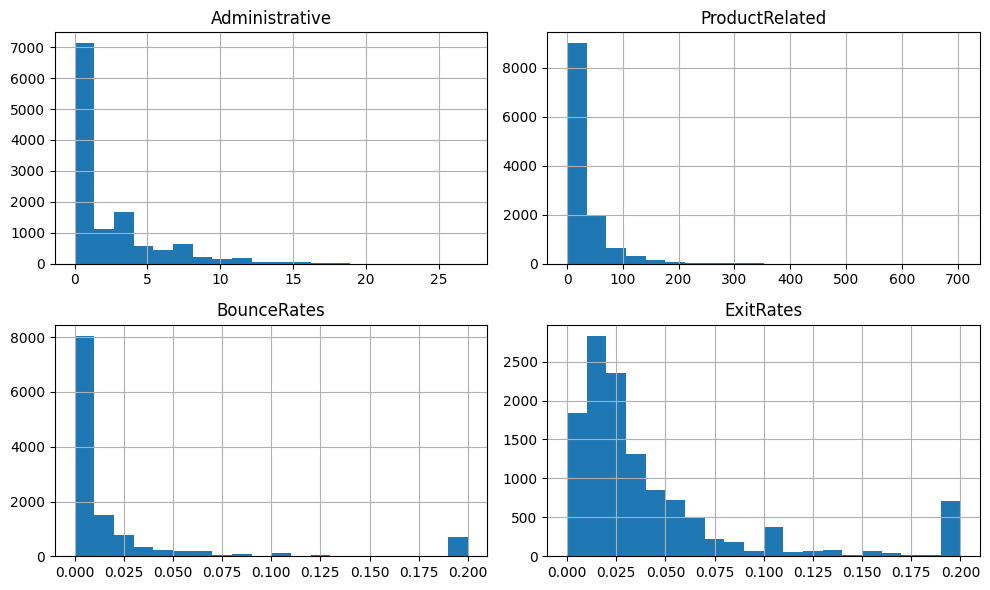

In [48]:
# Visualize distributions of selected numerical features
df[['Administrative', 'ProductRelated', 'BounceRates', 'ExitRates']].hist(
    bins=20, figsize=(10, 6)
)
plt.tight_layout()
plt.show()

#3.1.1.2(c) Insights from Exploratory Data Analysis

The target variable Revenue is highly imbalanced, with a much larger number of non-purchasing sessions compared to purchasing sessions.

Sessions with higher values of ProductRelated and ProductRelated_Duration are more likely to result in revenue, indicating that deeper product exploration increases purchase likelihood.

PageValues shows a strong positive association with purchasing behavior, making it a key predictive feature.

Higher BounceRates and ExitRates are associated with non-purchasing sessions, suggesting that early exits reduce the probability of conversion.

Correlation analysis indicates no severe multicollinearity among most numerical features, supporting their suitability for use in classification models.

2. Build a Neural Network Model [15]

In [49]:
#3.1.2(a) Prepare features/target and split into train/test (stratified)

# Features and target
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

# Convert categorical variables into numeric form
X = pd.get_dummies(X, drop_first=True)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Train shape: (9864, 26) | Test shape: (2466, 26)


In [50]:
#3.1.2(b) Design and implement a Neural Network-based classifier (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

In [51]:
#3.1.2(c) Train the neural network model

mlp.fit(X_train_scaled, y_train)
print("Model training completed.")


Model training completed.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [52]:
#3.1.2(d) Evaluate on training and test sets using classification metrics
# Predictions
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Training metrics
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Training Metrics:")
print("Accuracy:", train_acc)
print("Precision:", train_prec)
print("Recall:", train_rec)
print("F1-score:", train_f1)

print("\nTesting Metrics:")
print("Accuracy:", test_acc)
print("Precision:", test_prec)
print("Recall:", test_rec)
print("F1-score:", test_f1)

Training Metrics:
Accuracy: 0.9831711273317113
Precision: 0.9651162790697675
Recall: 0.9246395806028833
F1-score: 0.9444444444444444

Testing Metrics:
Accuracy: 0.8718572587185726
Precision: 0.5982142857142857
Recall: 0.5261780104712042
F1-score: 0.5598885793871866


3. Build a Primary Model [20] (Two Classical ML Models):

In [54]:
#3.1.3(a) Split the dataset into training and testing sets (for Classical ML Models)
# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_lr = lr.predict(X_test_scaled)

In [55]:
# Evaluate Logistic Regression model
accuracy_score(y_test, y_pred_lr), \
precision_score(y_test, y_pred_lr, average="weighted", zero_division=0), \
recall_score(y_test, y_pred_lr, average="weighted", zero_division=0), \
f1_score(y_test, y_pred_lr, average="weighted", zero_division=0)


(0.8811841038118411, 0.869153912714144, 0.8811841038118411, 0.8629670516600086)

In [56]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)
# Evaluate Random Forest model
accuracy_score(y_test, y_pred_rf), \
precision_score(y_test, y_pred_rf, average="weighted", zero_division=0), \
recall_score(y_test, y_pred_rf, average="weighted", zero_division=0), \
f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)


(0.8978102189781022,
 0.8900800859007029,
 0.8978102189781022,
 0.8911581260278212)

In [57]:
# Store model performance results
results = {
    "Model": [
        "Neural Network",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred),   # from MLP
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
    ]
}

In [58]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network,0.871857,0.865948,0.871857,0.868452
1,Logistic Regression,0.881184,0.869154,0.881184,0.862967
2,Random Forest,0.897810,0.890080,0.897810,0.891158


In [59]:
# Identify best model based on F1-score
comparison_df.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.897810,0.890080,0.897810,0.891158
0,Neural Network,0.871857,0.865948,0.871857,0.868452
1,Logistic Regression,0.881184,0.869154,0.881184,0.862967


4. Hyper-parameter Optimization with Cross-Validation [15]:

In [60]:
#3.1.4 Hyper-parameter Optimization with Cross-Validation [15]

#3.1.5(a) Logistic Regression hyperparameter grid
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

In [62]:
#3.1.4(b) Apply GridSearchCV for Logistic Regression (5-fold CV)
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid_lr.fit(X_train_scaled, y_train);


In [63]:
#3.1.4(c) Best hyperparameters and best CV score for Logistic Regression
grid_lr.best_params_, grid_lr.best_score_


({'C': 10}, np.float64(0.8687581492537279))

#Model 2: Random Forest Classifier (GridSearchCV)

In [65]:
#3.1.4(d) Random Forest hyperparameter grid
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

In [67]:
#3.1.4(e) Apply GridSearchCV for Random Forest (5-fold CV)
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid_rf.fit(X_train, y_train);


In [68]:
#3.1.4(f) Best hyperparameters and best CV score for Random Forest
grid_rf.best_params_, grid_rf.best_score_


({'max_depth': None, 'n_estimators': 200}, np.float64(0.9014304060397347))

5. Feature Selection [10]:

In [69]:
#3.1.5(a) Feature Selection for Logistic Regression (Embedded)

# Extract Logistic Regression coefficients from best estimator
lr_coefficients = grid_lr.best_estimator_.coef_

# Compute absolute coefficient importance (binary class -> take abs of coefficients)
lr_importance = np.abs(lr_coefficients[0])

# Create DataFrame for feature importance
lr_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lr_importance
})

# Sort features by importance (descending)
lr_feature_importance = lr_feature_importance.sort_values(
    by="Importance", ascending=False
)

lr_feature_importance


,Feature,Importance
8,PageValues,1.539664
7,ExitRates,0.807080
20,Month_May,0.273028
6,BounceRates,0.254588
16,Month_Feb,0.246885
19,Month_Mar,0.213630
15,Month_Dec,0.200000
21,Month_Nov,0.176083
4,ProductRelated,0.093142
25,VisitorType_Returning_Visitor,0.083659


In [70]:
# Select top 10 features from Logistic Regression
lr_selected_features = lr_feature_importance["Feature"].head(10).tolist()
lr_selected_features

['PageValues',
 'ExitRates',
 'Month_May',
 'BounceRates',
 'Month_Feb',
 'Month_Mar',
 'Month_Dec',
 'Month_Nov',
 'ProductRelated',
 'VisitorType_Returning_Visitor']

In [71]:
#3.1.5(b) Feature Selection for Random Forest (Embedded)

# Extract feature importance from best Random Forest estimator
rf_importance = grid_rf.best_estimator_.feature_importances_

# Create DataFrame for feature importance
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_importance
})

# Sort features by importance (descending)
rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance", ascending=False
)

rf_feature_importance


,Feature,Importance
8,PageValues,0.365884
7,ExitRates,0.091978
5,ProductRelated_Duration,0.089247
4,ProductRelated,0.071022
1,Administrative_Duration,0.058222
6,BounceRates,0.056087
0,Administrative,0.042522
13,TrafficType,0.031882
12,Region,0.031162
3,Informational_Duration,0.026272


In [72]:
#3 Select top 10 features from Random Forest
rf_selected_features = rf_feature_importance["Feature"].head(10).tolist()
rf_selected_features


['PageValues',
 'ExitRates',
 'ProductRelated_Duration',
 'ProductRelated',
 'Administrative_Duration',
 'BounceRates',
 'Administrative',
 'TrafficType',
 'Region',
 'Informational_Duration']

#3.1.5(c) Justification (Short)

Embedded feature selection was applied for both models. Logistic Regression uses the magnitude of learned coefficients to indicate feature influence, while Random Forest provides feature importance based on how much each feature contributes to reducing impurity in the trees. These methods are efficient and directly connected to model training, making them appropriate for selecting important predictors for this dataset.

In [87]:
#3.1.6(a) Rebuild Models Using Selected Features
# Use Random Forest selected features as the final selected feature set (simple + strong)
selected_features = rf_selected_features

# Create dataset using selected features
X_selected = X[selected_features]

X_selected.head()


,PageValues,ExitRates,ProductRelated_Duration,ProductRelated,Administrative_Duration,BounceRates,Administrative,TrafficType,Region,Informational_Duration
0,0.0,0.20,0.000000,1,0.0,0.20,0,1,1,0.0
1,0.0,0.10,64.000000,2,0.0,0.00,0,2,1,0.0
2,0.0,0.20,0.000000,1,0.0,0.20,0,3,9,0.0
3,0.0,0.14,2.666667,2,0.0,0.05,0,4,2,0.0
4,0.0,0.05,627.500000,10,0.0,0.02,0,4,1,0.0


In [88]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_sel.shape, X_test_sel.shape

((9864, 10), (2466, 10))

In [89]:
scaler_sel = StandardScaler()

X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

In [90]:
final_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    **grid_lr.best_params_
)

In [93]:
#3.1.6 Train and predict using final Logistic Regression model

# Train final Logistic Regression model (must run before predict)
final_lr.fit(X_train_sel_scaled, y_train_sel)

# Predict on test set
y_pred_final_lr = final_lr.predict(X_test_sel_scaled)

print("Final Logistic Regression trained and predictions generated.")

Final Logistic Regression trained and predictions generated.


In [94]:
lr_accuracy = accuracy_score(y_test_sel, y_pred_final_lr)
lr_precision = precision_score(y_test_sel, y_pred_final_lr, zero_division=0)
lr_recall = recall_score(y_test_sel, y_pred_final_lr, zero_division=0)
lr_f1 = f1_score(y_test_sel, y_pred_final_lr, zero_division=0)

lr_accuracy, lr_precision, lr_recall, lr_f1

(0.8791565287915653,
 0.7413793103448276,
 0.337696335078534,
 0.46402877697841727)

In [96]:
#3.1.6 Build Random Forest with optimal hyperparameters (Task 4)

final_rf = RandomForestClassifier(
    random_state=42,
    **grid_rf.best_params_
)

In [97]:
# Train Random Forest model
final_rf.fit(X_train_sel, y_train_sel)

# Predict on test set
y_pred_final_rf = final_rf.predict(X_test_sel)

In [98]:
# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test_sel, y_pred_final_rf)
rf_precision = precision_score(y_test_sel, y_pred_final_rf, average="weighted", zero_division=0)
rf_recall = recall_score(y_test_sel, y_pred_final_rf, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test_sel, y_pred_final_rf, average="weighted", zero_division=0)

rf_accuracy, rf_precision, rf_recall, rf_f1

(0.8933495539334956,
 0.8849549617363139,
 0.8933495539334956,
 0.8864877217341048)

In [99]:
#3.1.6 Create comparison table

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Features": [
        f"Selected ({len(selected_features)})",
        f"Selected ({len(selected_features)})"
    ],
    "CV Score": [
        grid_lr.best_score_,
        grid_rf.best_score_
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ]
})

comparison_table


,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Selected (10),0.868758,0.879157,0.741379,0.337696,0.464029
1,Random Forest,Selected (10),0.901430,0.893350,0.884955,0.893350,0.886488


In [100]:
#3.1.6 Identify best final model based on F1-Score

comparison_table.sort_values(by="F1-Score", ascending=False)


,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
1,Random Forest,Selected (10),0.901430,0.893350,0.884955,0.893350,0.886488
0,Logistic Regression,Selected (10),0.868758,0.879157,0.741379,0.337696,0.464029
